# Random Variables — Worked Examples

A collection of worked problems covering all distributions from Part 2.
Each problem states the setup, identifies the distribution, solves step-by-step, and verifies with Python.

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from math import comb, factorial, exp
from fractions import Fraction

np.random.seed(42)
print("Libraries loaded!")

Libraries loaded!


---
## 1. Bernoulli & Binomial

### Example 1.1 — Spam Filter

An email spam filter has an accuracy of 95% (correctly classifies each email). You receive 20 emails.

**(a)** What is the probability that all 20 are classified correctly?
**(b)** What is the probability that at most 2 are misclassified?
**(c)** What is the expected number of misclassifications?

**Identify the distribution:** Each email is an independent trial with $p = 0.05$ (misclassification). Number of misclassifications $X \sim \text{Bin}(n=20, p=0.05)$.

(a) P(X = 0) = P(all correct)
    = C(20,0) × 0.05⁰ × 0.95²⁰
    = 1 × 1 × 0.358486
    = 0.358486

(b) P(X ≤ 2) = P(X=0) + P(X=1) + P(X=2)
    P(X=0) = C(20,0) × 0.05^0 × 0.95^20 = 0.358486
    P(X=1) = C(20,1) × 0.05^1 × 0.95^19 = 0.377354
    P(X=2) = C(20,2) × 0.05^2 × 0.95^18 = 0.188677
    P(X ≤ 2) = 0.924516

(c) E[X] = np = 20 × 0.05 = 1.0
    Var(X) = np(1-p) = 20 × 0.05 × 0.95 = 0.95


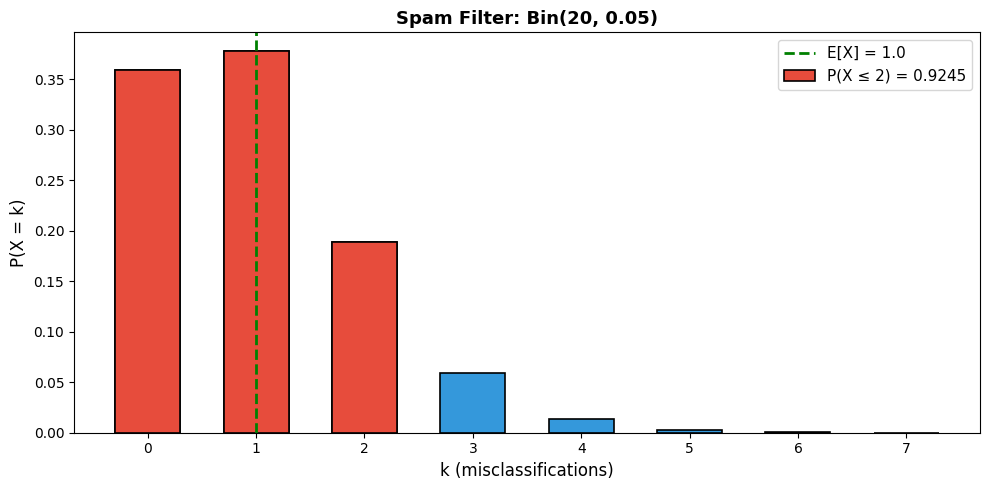

In [2]:
n, p = 20, 0.05
X = stats.binom(n, p)

# (a) All classified correctly = 0 misclassifications
p_a = X.pmf(0)
print("(a) P(X = 0) = P(all correct)")
print(f"    = C(20,0) × 0.05⁰ × 0.95²⁰")
print(f"    = 1 × 1 × {0.95**20:.6f}")
print(f"    = {p_a:.6f}")
print()

# (b) At most 2 misclassified
p_b = X.cdf(2)
print("(b) P(X ≤ 2) = P(X=0) + P(X=1) + P(X=2)")
for k in range(3):
    print(f"    P(X={k}) = C(20,{k}) × 0.05^{k} × 0.95^{20-k} = {X.pmf(k):.6f}")
print(f"    P(X ≤ 2) = {p_b:.6f}")
print()

# (c) Expected misclassifications
print(f"(c) E[X] = np = 20 × 0.05 = {X.mean()}")
print(f"    Var(X) = np(1-p) = 20 × 0.05 × 0.95 = {X.var()}")

# Visualize
fig, ax = plt.subplots(figsize=(10, 5))
k = np.arange(0, 8)
ax.bar(k, X.pmf(k), color='#3498db', edgecolor='black', linewidth=1.2, width=0.6)
ax.bar([0, 1, 2], [X.pmf(i) for i in range(3)], color='#e74c3c', edgecolor='black',
       linewidth=1.2, width=0.6, label=f'P(X ≤ 2) = {p_b:.4f}')
ax.axvline(X.mean(), color='green', linewidth=2, linestyle='--', label=f'E[X] = {X.mean()}')
ax.set_xlabel('k (misclassifications)', fontsize=12)
ax.set_ylabel('P(X = k)', fontsize=12)
ax.set_title('Spam Filter: Bin(20, 0.05)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.set_xticks(k)
plt.tight_layout()
plt.show()

### Example 1.2 — Quality Control

A factory produces chips with a 2% defect rate. A batch of 500 chips is tested.

**(a)** What is the expected number of defective chips?
**(b)** What is the probability of finding exactly 10 defectives?
**(c)** What is the probability of finding more than 15 defectives?
**(d)** Use both exact Binomial and Normal approximation. Compare.

**Distribution:** $X \sim \text{Bin}(n=500, p=0.02)$. Since $np = 10$ and $n(1-p) = 490$, Normal approx applies.

Distribution: Bin(500, 0.02),  μ = np = 10.0,  σ = √(np(1-p)) = 3.1305

(a) E[X] = np = 10.0

(b) P(X = 10):
    Exact (Binomial):  0.126380
    Normal approx:     0.126898   (with continuity correction)

(c) P(X > 15):
    Exact (Binomial):  0.046997
    Normal approx:     0.039467
    Poisson approx:    P(X=10) = 0.125110,  P(X>15) = 0.048740


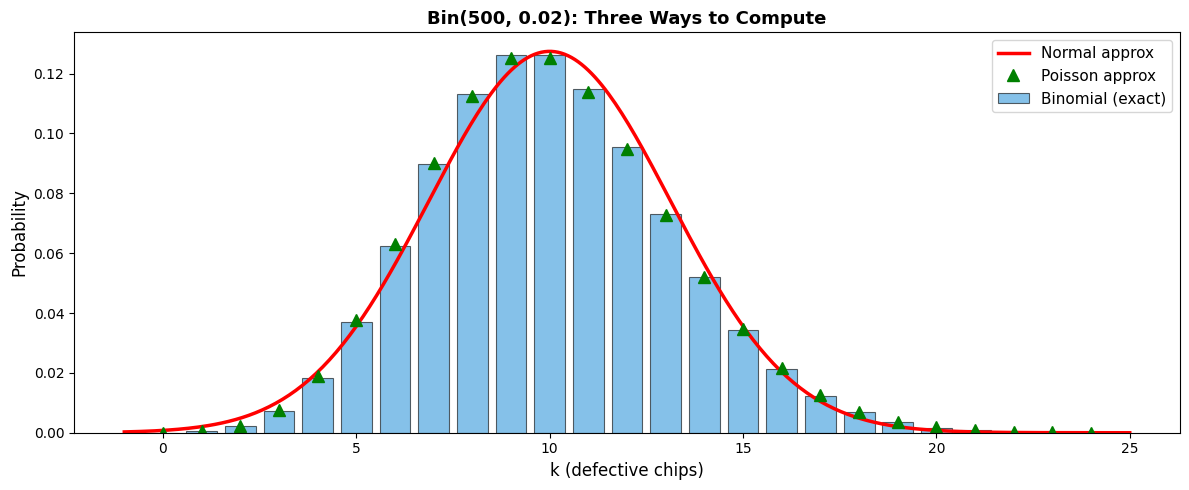

In [3]:
n, p = 500, 0.02
X_bin = stats.binom(n, p)
mu, sigma = n * p, np.sqrt(n * p * (1 - p))
X_norm = stats.norm(mu, sigma)

print(f"Distribution: Bin(500, 0.02),  μ = np = {mu},  σ = √(np(1-p)) = {sigma:.4f}")
print()

# (a)
print(f"(a) E[X] = np = {mu}")
print()

# (b) P(X = 10)
p_exact = X_bin.pmf(10)
p_normal = X_norm.cdf(10.5) - X_norm.cdf(9.5)  # continuity correction
print(f"(b) P(X = 10):")
print(f"    Exact (Binomial):  {p_exact:.6f}")
print(f"    Normal approx:     {p_normal:.6f}   (with continuity correction)")
print()

# (c) P(X > 15)
p_exact_c = 1 - X_bin.cdf(15)
p_normal_c = 1 - X_norm.cdf(15.5)  # continuity correction
print(f"(c) P(X > 15):")
print(f"    Exact (Binomial):  {p_exact_c:.6f}")
print(f"    Normal approx:     {p_normal_c:.6f}")

# Also try Poisson since p is small
X_poi = stats.poisson(mu)
p_poi_b = X_poi.pmf(10)
p_poi_c = 1 - X_poi.cdf(15)
print(f"    Poisson approx:    P(X=10) = {p_poi_b:.6f},  P(X>15) = {p_poi_c:.6f}")

# (d) Visual comparison
fig, ax = plt.subplots(figsize=(12, 5))
k = np.arange(0, 25)
x_cont = np.linspace(-1, 25, 300)

ax.bar(k, X_bin.pmf(k), color='#3498db', edgecolor='black', linewidth=0.8,
       alpha=0.6, width=0.8, label='Binomial (exact)')
ax.plot(x_cont, X_norm.pdf(x_cont), 'r-', linewidth=2.5, label='Normal approx')
ax.plot(k, X_poi.pmf(k), 'g^', markersize=8, label='Poisson approx')
ax.set_xlabel('k (defective chips)', fontsize=12)
ax.set_ylabel('Probability', fontsize=12)
ax.set_title('Bin(500, 0.02): Three Ways to Compute', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

---
## 2. Poisson

### Example 2.1 — Website Traffic

A website receives an average of 4 visits per minute.

**(a)** What is the probability of exactly 6 visits in a given minute?
**(b)** What is the probability of no visits in 30 seconds?
**(c)** What is the probability of more than 10 visits in 2 minutes?

**Distribution:** Visits per minute $\sim \text{Poi}(\lambda = 4)$.

(a) P(X = 6) = λ⁶ × e^(-λ) / 6!
    = 4⁶ × e⁻⁴ / 720
    = 4096 × 0.018316 / 720
    = 0.104196

(b) 30 seconds → λ = 4/2 = 2
    P(Y = 0) = e^(-2) = 0.135335

(c) 2 minutes → λ = 4 × 2 = 8
    P(Z > 10) = 1 - P(Z ≤ 10)
    = 1 - 0.815886 = 0.184114


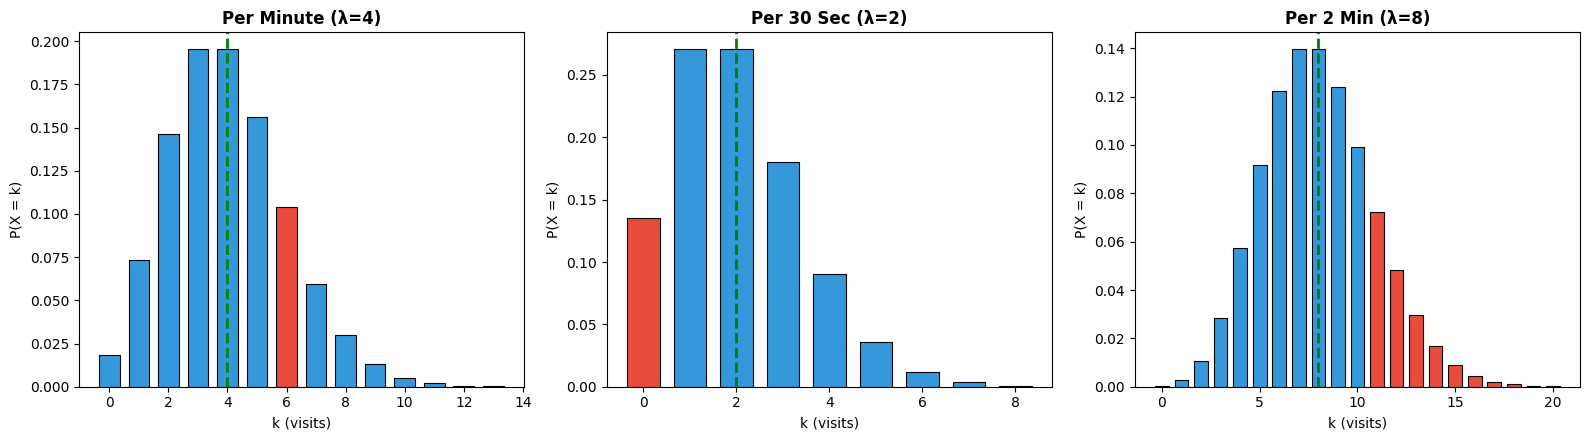

In [4]:
# (a) P(X = 6) where X ~ Poi(4)
lam = 4
X = stats.poisson(lam)

p_a = X.pmf(6)
print(f"(a) P(X = 6) = λ⁶ × e^(-λ) / 6!")
print(f"    = 4⁶ × e⁻⁴ / 720")
print(f"    = {4**6} × {exp(-4):.6f} / 720")
print(f"    = {p_a:.6f}")
print()

# (b) In 30 seconds: λ = 4/2 = 2 visits per 30s
lam_30s = 2
Y = stats.poisson(lam_30s)
p_b = Y.pmf(0)
print(f"(b) 30 seconds → λ = 4/2 = 2")
print(f"    P(Y = 0) = e^(-2) = {p_b:.6f}")
print()

# (c) In 2 minutes: λ = 4 × 2 = 8
lam_2m = 8
Z = stats.poisson(lam_2m)
p_c = 1 - Z.cdf(10)
print(f"(c) 2 minutes → λ = 4 × 2 = 8")
print(f"    P(Z > 10) = 1 - P(Z ≤ 10)")
print(f"    = 1 - {Z.cdf(10):.6f} = {p_c:.6f}")

# Visualize all three intervals
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, rv, lam_v, title, highlight in [
    (axes[0], X, lam, "Per Minute (λ=4)", 6),
    (axes[1], Y, lam_30s, "Per 30 Sec (λ=2)", 0),
    (axes[2], Z, lam_2m, "Per 2 Min (λ=8)", None),
]:
    k = np.arange(0, int(lam_v + 4 * np.sqrt(lam_v)) + 2)
    colors = ['#e74c3c' if (highlight is not None and ki == highlight) or
              (highlight is None and ki > 10) else '#3498db' for ki in k]
    ax.bar(k, rv.pmf(k), color=colors, edgecolor='black', linewidth=0.8, width=0.7)
    ax.axvline(rv.mean(), color='green', linewidth=2, linestyle='--')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('k (visits)')
    ax.set_ylabel('P(X = k)')
plt.tight_layout()
plt.show()

### Example 2.2 — Rare Disease

In a city of 100,000 people, a disease affects 0.003% of the population.

**(a)** What is the expected number of cases?
**(b)** What is the probability of 0 cases?
**(c)** What is the probability of 5 or more cases?

**Distribution:** $X \sim \text{Bin}(100000, 0.00003) \approx \text{Poi}(\lambda = 3)$

In [5]:
n, p = 100000, 0.00003
lam = n * p
X = stats.poisson(lam)

print(f"λ = np = {n} × {p} = {lam}")
print()

# (a) Expected cases
print(f"(a) E[X] = λ = {lam}")
print()

# (b) P(X = 0)
p_b = X.pmf(0)
print(f"(b) P(X = 0) = e^(-3) = {p_b:.6f}")
print()

# (c) P(X ≥ 5)
p_c = 1 - X.cdf(4)
print(f"(c) P(X ≥ 5) = 1 - P(X ≤ 4)")
print(f"    P(X ≤ 4) = ", end="")
terms = [f"P({k})={X.pmf(k):.4f}" for k in range(5)]
print(" + ".join(terms))
print(f"    = {X.cdf(4):.6f}")
print(f"    P(X ≥ 5) = {p_c:.6f}")

# Compare with exact binomial
X_bin = stats.binom(n, p)
print(f"\n    Exact Binomial: P(X ≥ 5) = {1 - X_bin.cdf(4):.6f}")
print(f"    Poisson approx: P(X ≥ 5) = {p_c:.6f}")
print(f"    Difference: {abs(p_c - (1 - X_bin.cdf(4))):.8f} (excellent approximation)")

λ = np = 100000 × 3e-05 = 3.0

(a) E[X] = λ = 3.0

(b) P(X = 0) = e^(-3) = 0.049787

(c) P(X ≥ 5) = 1 - P(X ≤ 4)
    P(X ≤ 4) = P(0)=0.0498 + P(1)=0.1494 + P(2)=0.2240 + P(3)=0.2240 + P(4)=0.1680
    = 0.815263
    P(X ≥ 5) = 0.184737

    Exact Binomial: P(X ≥ 5) = 0.184734
    Poisson approx: P(X ≥ 5) = 0.184737
    Difference: 0.00000252 (excellent approximation)


---
## 3. Geometric

### Example 3.1 — Debugging

A programmer fixes a bug with probability 0.3 on each attempt (independent attempts).

**(a)** What is the probability the bug is fixed on the 4th attempt?
**(b)** What is the expected number of attempts?
**(c)** Given that the first 3 attempts failed, what is the probability it takes at least 7 total attempts?

**Distribution:** $X \sim \text{Geo}(p = 0.3)$. $X$ = attempt number of first success.

(a) P(X = 4) = (1-p)³ × p = 0.7³ × 0.3
    = 0.3430 × 0.3 = 0.102900

(b) E[X] = 1/p = 1/0.3 = 3.3333 attempts
    Var(X) = (1-p)/p² = 7.7778

(c) By memoryless property:
    P(X ≥ 7 | X > 3) = P(X ≥ 4) = (0.7)³ = 0.343000
    Direct: P(X ≥ 7)/P(X > 3) = 0.117649/0.343000 = 0.343000
    Match ✓


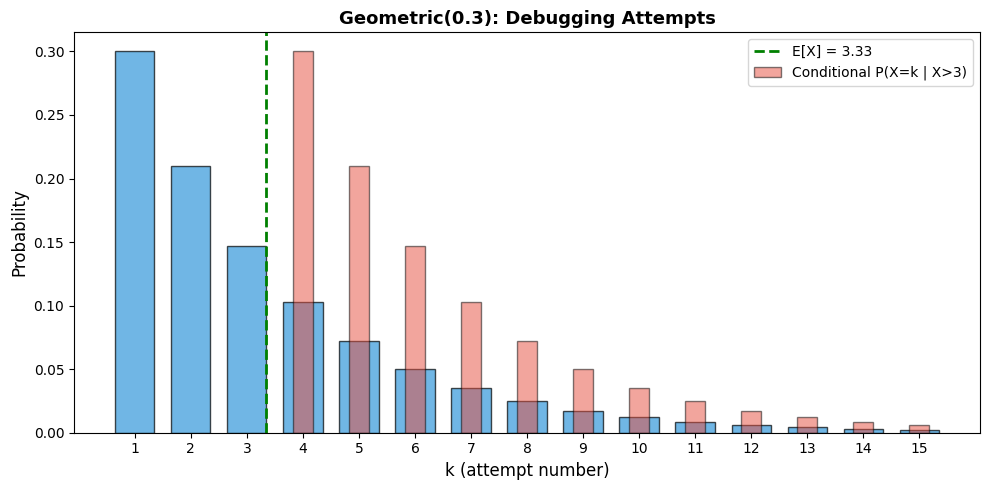

In [6]:
p = 0.3
X = stats.geom(p)

# (a) P(X = 4) = (1-p)^3 × p
p_a = X.pmf(4)
print(f"(a) P(X = 4) = (1-p)³ × p = 0.7³ × 0.3")
print(f"    = {0.7**3:.4f} × 0.3 = {p_a:.6f}")
print()

# (b) E[X] = 1/p
print(f"(b) E[X] = 1/p = 1/0.3 = {1/p:.4f} attempts")
print(f"    Var(X) = (1-p)/p² = {(1-p)/p**2:.4f}")
print()

# (c) Memoryless property!
# P(X ≥ 7 | X > 3) = P(X ≥ 4) = P(X > 3) = (1-p)^3
# (need 4 more successes from attempt 4 onwards = same as starting fresh)
p_c = (1 - p) ** 3
p_c_direct = X.sf(6)  # P(X > 6) — wait, let me recalculate
# P(X ≥ 7 | X > 3) = P(X > 3 + 3 | X > 3) = P(X > 3) by memoryless
p_memoryless = (1 - p) ** 3

# Verify by direct computation
# P(X ≥ 7 | X > 3) = P(X ≥ 7 and X > 3) / P(X > 3) = P(X ≥ 7) / P(X > 3)
p_ge_7 = 1 - X.cdf(6)   # P(X ≥ 7)
p_gt_3 = 1 - X.cdf(3)   # P(X > 3)
p_conditional = p_ge_7 / p_gt_3

print(f"(c) By memoryless property:")
print(f"    P(X ≥ 7 | X > 3) = P(X ≥ 4) = (0.7)³ = {p_memoryless:.6f}")
print(f"    Direct: P(X ≥ 7)/P(X > 3) = {p_ge_7:.6f}/{p_gt_3:.6f} = {p_conditional:.6f}")
print(f"    Match ✓")

# Visualize
fig, ax = plt.subplots(figsize=(10, 5))
k = np.arange(1, 16)
ax.bar(k, X.pmf(k), color='#3498db', edgecolor='black', linewidth=1, width=0.7, alpha=0.7)
# Highlight k ≥ 7 given X > 3
colors_cond = ['#e74c3c' if ki >= 7 else '#95a5a6' for ki in range(4, 16)]
ax.bar(range(4, 16), [X.pmf(ki) / p_gt_3 if ki >= 4 else 0 for ki in range(4, 16)],
       color='#e74c3c', edgecolor='black', linewidth=1, width=0.35, alpha=0.5,
       label='Conditional P(X=k | X>3)')
ax.axvline(X.mean(), color='green', linewidth=2, linestyle='--', label=f'E[X] = {X.mean():.2f}')
ax.set_xlabel('k (attempt number)', fontsize=12)
ax.set_ylabel('Probability', fontsize=12)
ax.set_title('Geometric(0.3): Debugging Attempts', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.set_xticks(k)
plt.tight_layout()
plt.show()

---
## 4. Negative Binomial

### Example 4.1 — Recruiting

A recruiter needs to hire 5 engineers. Each candidate has a 0.2 probability of passing all interviews.

**(a)** What is the expected number of candidates to interview?
**(b)** What is the probability of hiring all 5 within the first 20 candidates?
**(c)** What is the probability the 5th hire is exactly the 25th candidate?

**Distribution:** $X \sim \text{NegBin}(r=5, p=0.2)$. $X$ = total candidates until 5 hires.

(a) E[total candidates] = r/p = 5/0.2 = 25.0
    E[failures] = r(1-p)/p = 20.0
    Std dev = √(r(1-p)/p²) = 10.00

(b) P(total ≤ 20) = P(failures ≤ 15) = 0.370352

(c) P(5th hire on 25th candidate)
    = C(24,4) × 0.2⁴ × 0.8²⁰ × 0.2
    = 10626 × 0.001600 × 0.011529 × 0.2
    = 0.039203
    scipy check: 0.039203 ✓


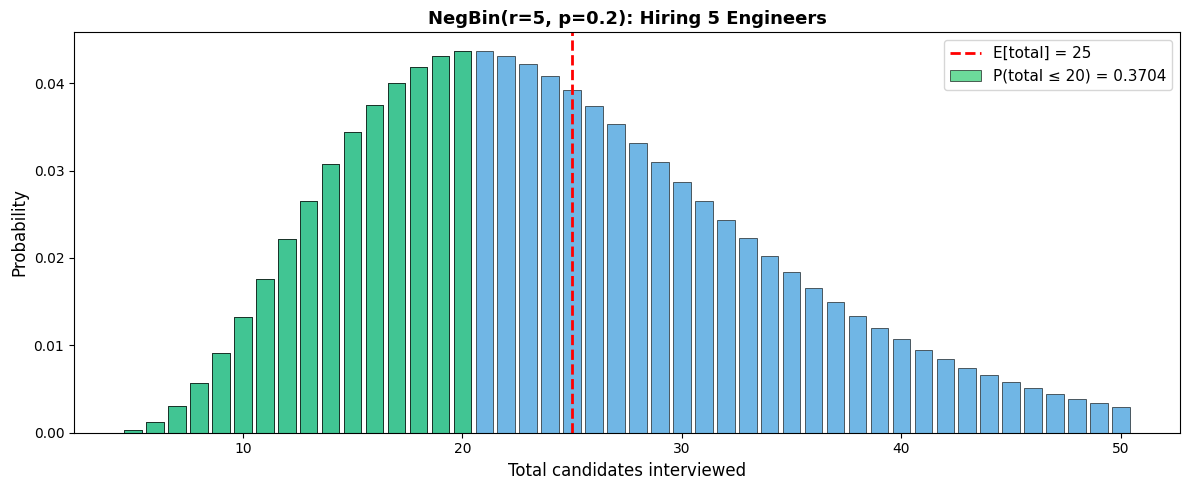

In [7]:
r, p = 5, 0.2

# scipy.stats.nbinom counts FAILURES before r successes
# So failures = total - r
rv = stats.nbinom(r, p)

# (a) E[total candidates] = r/p
E_total = r / p
print(f"(a) E[total candidates] = r/p = 5/0.2 = {E_total}")
print(f"    E[failures] = r(1-p)/p = {r*(1-p)/p}")
print(f"    Std dev = √(r(1-p)/p²) = {np.sqrt(r*(1-p)/p**2):.2f}")
print()

# (b) P(total ≤ 20) = P(failures ≤ 15)
p_b = rv.cdf(15)  # 15 failures = 20 total - 5 successes
print(f"(b) P(total ≤ 20) = P(failures ≤ 15) = {p_b:.6f}")
print()

# (c) P(5th hire on 25th candidate)
# Need exactly 4 hires in first 24, then hire on 25th
# P = C(24,4) × p^4 × (1-p)^20 × p
from math import comb
p_c = comb(24, 4) * p**4 * (1-p)**20 * p
# Equivalently: P(failures = 20) in NegBin
p_c_scipy = rv.pmf(20)  # 20 failures = 25 total - 5 successes
print(f"(c) P(5th hire on 25th candidate)")
print(f"    = C(24,4) × 0.2⁴ × 0.8²⁰ × 0.2")
print(f"    = {comb(24,4)} × {p**4:.6f} × {(1-p)**20:.6f} × 0.2")
print(f"    = {p_c:.6f}")
print(f"    scipy check: {p_c_scipy:.6f} ✓")

# Visualize
fig, ax = plt.subplots(figsize=(12, 5))
total_candidates = np.arange(5, 51)
failures = total_candidates - r
pmf_vals = rv.pmf(failures)

ax.bar(total_candidates, pmf_vals, color='#3498db', edgecolor='black', linewidth=0.6, alpha=0.7)
ax.axvline(E_total, color='red', linewidth=2, linestyle='--', label=f'E[total] = {E_total:.0f}')
# Shade P(total ≤ 20)
mask = total_candidates <= 20
ax.bar(total_candidates[mask], pmf_vals[mask], color='#2ecc71', edgecolor='black',
       linewidth=0.6, alpha=0.7, label=f'P(total ≤ 20) = {p_b:.4f}')
ax.set_xlabel('Total candidates interviewed', fontsize=12)
ax.set_ylabel('Probability', fontsize=12)
ax.set_title('NegBin(r=5, p=0.2): Hiring 5 Engineers', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

---
## 5. Uniform & Exponential

### Example 5.1 — Bus Waiting Time

A bus arrives every 15 minutes. You arrive at a random time.

**(a)** What is the distribution of your waiting time?
**(b)** What is the expected wait?
**(c)** What is the probability you wait more than 10 minutes?
**(d)** What is the probability you wait between 3 and 8 minutes?

**Distribution:** $X \sim \text{Uni}(0, 15)$

(a) X ~ Uniform(0, 15)
    PDF: f(x) = 1/15 = 0.0667 for x ∈ [0, 15]

(b) E[X] = (a+b)/2 = (0+15)/2 = 7.5 minutes
    Std(X) = (b-a)/√12 = 4.33 minutes

(c) P(X > 10) = (15-10)/15 = 0.3333

(d) P(3 < X < 8) = (8-3)/15 = 0.3333


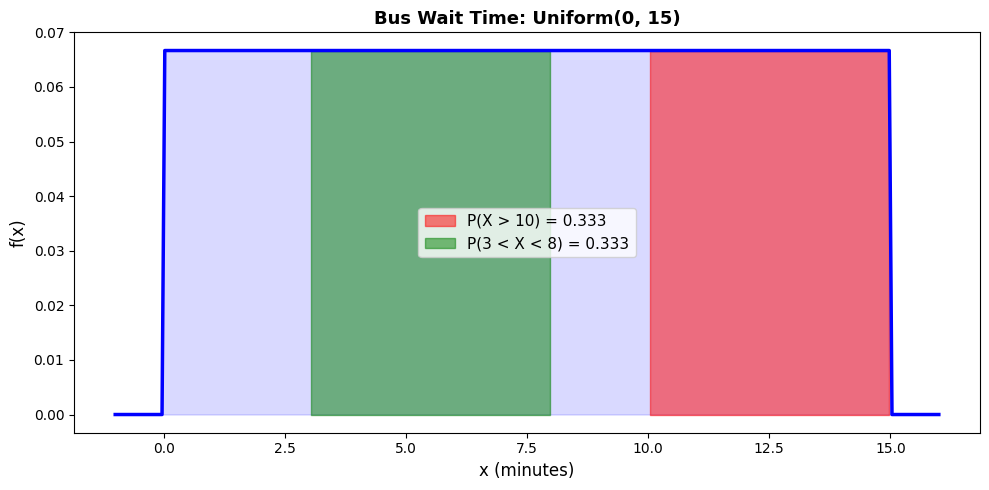

In [8]:
a, b = 0, 15
X = stats.uniform(loc=a, scale=b - a)

print(f"(a) X ~ Uniform(0, 15)")
print(f"    PDF: f(x) = 1/{b-a} = {1/(b-a):.4f} for x ∈ [0, 15]")
print()

print(f"(b) E[X] = (a+b)/2 = (0+15)/2 = {X.mean()} minutes")
print(f"    Std(X) = (b-a)/√12 = {X.std():.2f} minutes")
print()

p_c = 1 - X.cdf(10)
print(f"(c) P(X > 10) = (15-10)/15 = {p_c:.4f}")
print()

p_d = X.cdf(8) - X.cdf(3)
print(f"(d) P(3 < X < 8) = (8-3)/15 = {p_d:.4f}")

# Visual
fig, ax = plt.subplots(figsize=(10, 5))
x = np.linspace(-1, 16, 300)
ax.plot(x, X.pdf(x), 'b-', linewidth=2.5)
ax.fill_between(x, X.pdf(x), alpha=0.15, color='blue')

# Shade regions
mask_c = (x >= 10) & (x <= 15)
ax.fill_between(x[mask_c], X.pdf(x[mask_c]), alpha=0.5, color='red',
               label=f'P(X > 10) = {p_c:.3f}')
mask_d = (x >= 3) & (x <= 8)
ax.fill_between(x[mask_d], X.pdf(x[mask_d]), alpha=0.5, color='green',
               label=f'P(3 < X < 8) = {p_d:.3f}')
ax.set_xlabel('x (minutes)', fontsize=12)
ax.set_ylabel('f(x)', fontsize=12)
ax.set_title('Bus Wait Time: Uniform(0, 15)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

### Example 5.2 — Server Failures

A server has a mean time between failures of 200 hours.

**(a)** What is the probability it lasts more than 300 hours?
**(b)** Given it has already lasted 100 hours, what is the probability it lasts another 200 hours?
**(c)** What is the median lifetime?

**Distribution:** $X \sim \text{Exp}(\lambda = 1/200)$

(a) P(X > 300) = e^(-300/200) = e^(-1.5) = 0.223130

(b) By memoryless property:
    P(X > 300 | X > 100) = P(X > 200) = e^(-200/200) = e^(-1) = 0.367879

(c) Median = ln(2)/λ = ln(2) × 200 = 138.63 hours
    scipy check: 138.63 hours
    Note: median (138.6) < mean (200.0) — right-skewed!


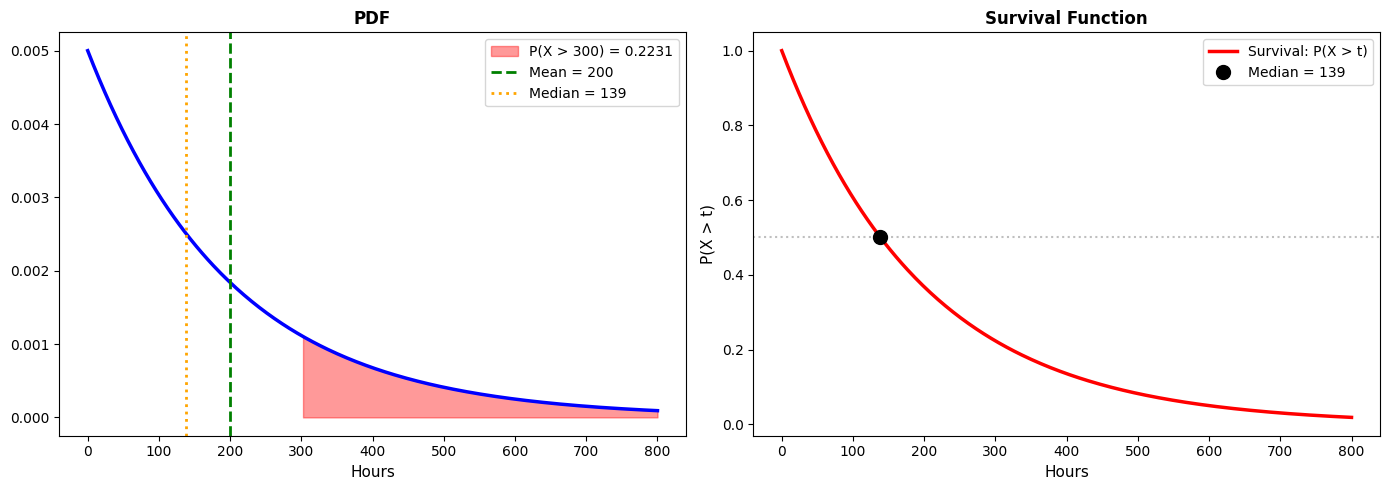

In [9]:
lam = 1/200  # rate
X = stats.expon(scale=200)  # scale = 1/λ = mean

# (a) P(X > 300)
p_a = X.sf(300)
print(f"(a) P(X > 300) = e^(-300/200) = e^(-1.5) = {p_a:.6f}")
print()

# (b) Memoryless! P(X > 300 | X > 100) = P(X > 200)
p_b = X.sf(200)
print(f"(b) By memoryless property:")
print(f"    P(X > 300 | X > 100) = P(X > 200) = e^(-200/200) = e^(-1) = {p_b:.6f}")
print()

# (c) Median: F(m) = 0.5 → m = ln(2)/λ
median = np.log(2) / lam
print(f"(c) Median = ln(2)/λ = ln(2) × 200 = {median:.2f} hours")
print(f"    scipy check: {X.median():.2f} hours")
print(f"    Note: median ({median:.1f}) < mean ({X.mean():.1f}) — right-skewed!")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.linspace(0, 800, 300)

ax = axes[0]
ax.plot(x, X.pdf(x), 'b-', linewidth=2.5)
ax.fill_between(x[x >= 300], X.pdf(x[x >= 300]), alpha=0.4, color='red',
               label=f'P(X > 300) = {p_a:.4f}')
ax.axvline(X.mean(), color='green', linewidth=2, linestyle='--', label=f'Mean = {X.mean():.0f}')
ax.axvline(median, color='orange', linewidth=2, linestyle=':', label=f'Median = {median:.0f}')
ax.set_title('PDF', fontsize=12, fontweight='bold')
ax.set_xlabel('Hours', fontsize=11)
ax.legend(fontsize=10)

ax = axes[1]
ax.plot(x, X.sf(x), 'r-', linewidth=2.5, label='Survival: P(X > t)')
ax.axhline(0.5, color='gray', linestyle=':', alpha=0.5)
ax.plot(median, 0.5, 'ko', markersize=10, label=f'Median = {median:.0f}')
ax.set_title('Survival Function', fontsize=12, fontweight='bold')
ax.set_xlabel('Hours', fontsize=11)
ax.set_ylabel('P(X > t)', fontsize=11)
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

---
## 6. Normal Distribution

### Example 6.1 — Exam Scores

Exam scores follow $N(\mu = 72, \sigma^2 = 100)$ (so $\sigma = 10$).

**(a)** What fraction of students scored above 90?
**(b)** What score is the 95th percentile?
**(c)** Between what two scores (symmetric around the mean) do 80% of students fall?
**(d)** If there are 200 students, how many scored between 60 and 80?

(a) z-score for 90: z = (90 - 72)/10 = 1.8
    P(X > 90) = P(Z > 1.8) = 0.035930 = 3.59%

(b) 95th percentile: x = μ + z₀.₉₅ × σ = 72 + 1.6449 × 10 = 88.45

(c) 80% of students between 59.18 and 84.82
    z = ±1.2816

(d) P(60 < X < 80) = 0.673075
    Expected students: 200 × 0.6731 = 134.6


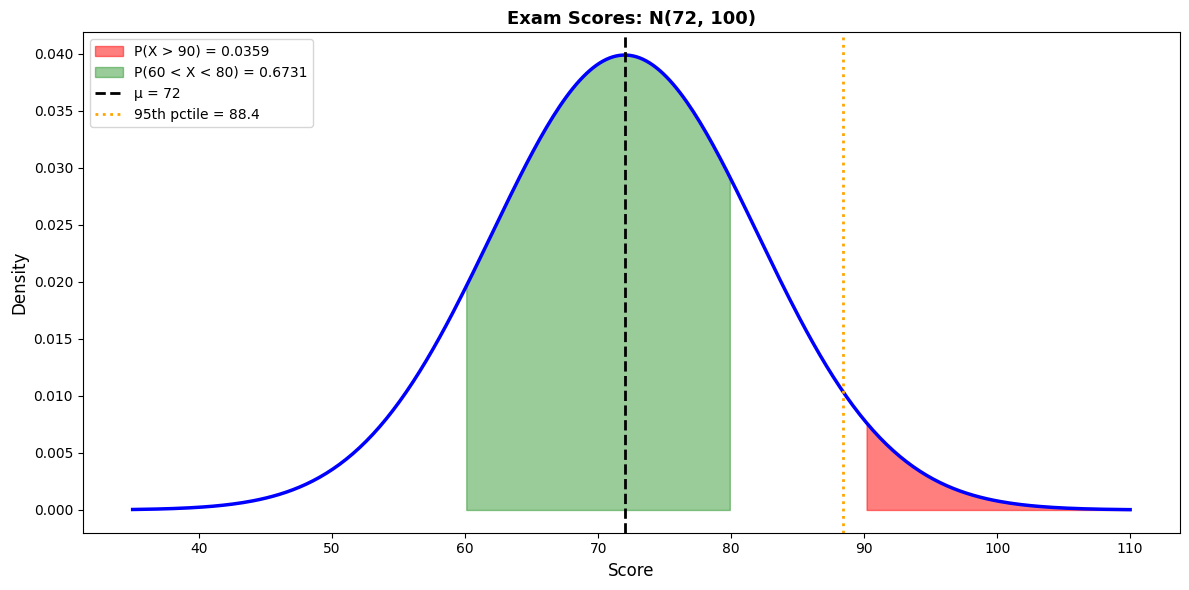

In [10]:
mu, sigma = 72, 10
X = stats.norm(mu, sigma)

# (a) P(X > 90)
z_90 = (90 - mu) / sigma
p_a = X.sf(90)
print(f"(a) z-score for 90: z = (90 - 72)/10 = {z_90}")
print(f"    P(X > 90) = P(Z > {z_90}) = {p_a:.6f} = {p_a*100:.2f}%")
print()

# (b) 95th percentile
x_95 = X.ppf(0.95)
print(f"(b) 95th percentile: x = μ + z₀.₉₅ × σ = 72 + {stats.norm.ppf(0.95):.4f} × 10 = {x_95:.2f}")
print()

# (c) 80% symmetric interval → 10% in each tail → z = ±1.2816
z_80 = stats.norm.ppf(0.90)
lower = mu - z_80 * sigma
upper = mu + z_80 * sigma
print(f"(c) 80% of students between {lower:.2f} and {upper:.2f}")
print(f"    z = ±{z_80:.4f}")
print()

# (d) 200 students between 60 and 80
p_60_80 = X.cdf(80) - X.cdf(60)
n_students = 200 * p_60_80
print(f"(d) P(60 < X < 80) = {p_60_80:.6f}")
print(f"    Expected students: 200 × {p_60_80:.4f} = {n_students:.1f}")

# Visualize
fig, ax = plt.subplots(figsize=(12, 6))
x = np.linspace(35, 110, 300)
ax.plot(x, X.pdf(x), 'b-', linewidth=2.5)

# Shade regions
mask_a = x >= 90
ax.fill_between(x[mask_a], X.pdf(x[mask_a]), alpha=0.5, color='red',
               label=f'P(X > 90) = {p_a:.4f}')
mask_d = (x >= 60) & (x <= 80)
ax.fill_between(x[mask_d], X.pdf(x[mask_d]), alpha=0.4, color='green',
               label=f'P(60 < X < 80) = {p_60_80:.4f}')

ax.axvline(mu, color='black', linewidth=2, linestyle='--', label=f'μ = {mu}')
ax.axvline(x_95, color='orange', linewidth=2, linestyle=':', label=f'95th pctile = {x_95:.1f}')
ax.set_xlabel('Score', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Exam Scores: N(72, 100)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10, loc='upper left')
plt.tight_layout()
plt.show()

### Example 6.2 — Manufacturing Tolerance

Steel rods are manufactured with mean length 50 cm and standard deviation 0.5 cm. Rods are rejected if they deviate from 50 cm by more than 1.2 cm.

**(a)** What fraction of rods is rejected?
**(b)** What standard deviation would ensure only 1% are rejected?

(a) Reject if X < 48.8 or X > 51.2
    z = 1.2/0.5 = 2.4
    P(accept) = P(-2.4 < Z < 2.4) = 0.983605
    P(reject) = 0.016395 = 1.64%

(b) Need P(|X - 50| > 1.2) = 0.01
    z* = Φ⁻¹(0.995) = 2.5758
    σ = 1.2 / z* = 1.2 / 2.5758 = 0.4659 cm
    Verify: P(reject) = 0.010000


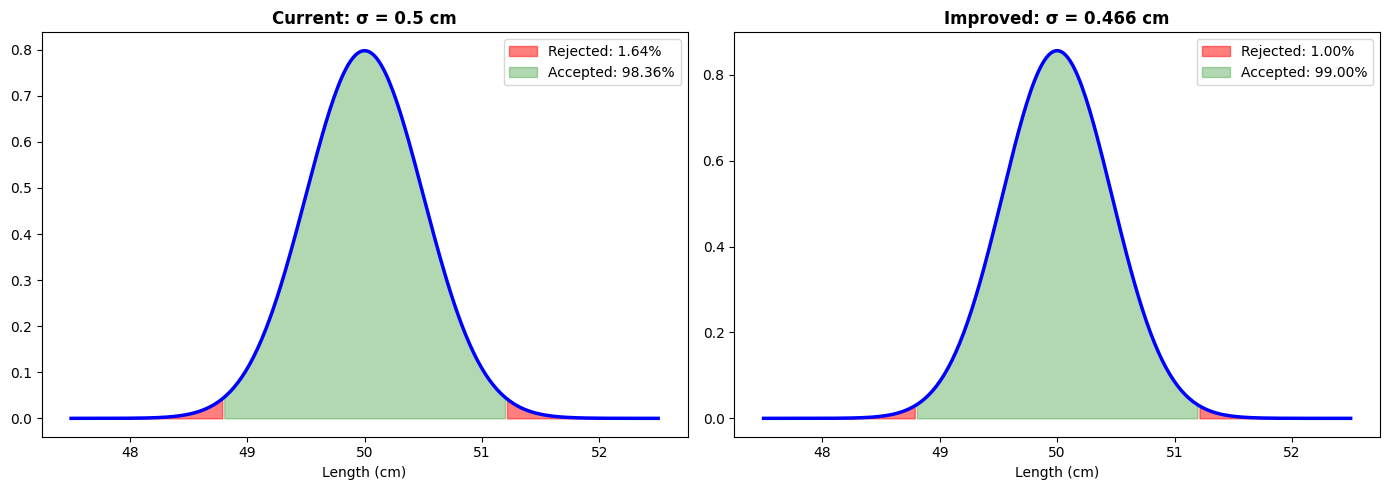

In [11]:
mu, sigma = 50, 0.5
X = stats.norm(mu, sigma)

# (a) Reject if |X - 50| > 1.2, i.e., X < 48.8 or X > 51.2
p_accept = X.cdf(51.2) - X.cdf(48.8)
p_reject = 1 - p_accept
z = 1.2 / sigma

print(f"(a) Reject if X < {mu - 1.2} or X > {mu + 1.2}")
print(f"    z = 1.2/0.5 = {z}")
print(f"    P(accept) = P(-{z} < Z < {z}) = {p_accept:.6f}")
print(f"    P(reject) = {p_reject:.6f} = {p_reject*100:.2f}%")
print()

# (b) Want P(reject) = 0.01 → P(|Z| > z*) = 0.01 → P(Z > z*) = 0.005
# z* = 2.576
z_star = stats.norm.ppf(0.995)
sigma_new = 1.2 / z_star
print(f"(b) Need P(|X - 50| > 1.2) = 0.01")
print(f"    z* = Φ⁻¹(0.995) = {z_star:.4f}")
print(f"    σ = 1.2 / z* = 1.2 / {z_star:.4f} = {sigma_new:.4f} cm")
print(f"    Verify: P(reject) = {1 - (stats.norm.cdf(1.2/sigma_new) - stats.norm.cdf(-1.2/sigma_new)):.6f}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Current
ax = axes[0]
x = np.linspace(47.5, 52.5, 300)
ax.plot(x, X.pdf(x), 'b-', linewidth=2.5)
ax.fill_between(x[x < 48.8], X.pdf(x[x < 48.8]), alpha=0.5, color='red')
ax.fill_between(x[x > 51.2], X.pdf(x[x > 51.2]), alpha=0.5, color='red',
               label=f'Rejected: {p_reject*100:.2f}%')
ax.fill_between(x[(x >= 48.8) & (x <= 51.2)],
               X.pdf(x[(x >= 48.8) & (x <= 51.2)]), alpha=0.3, color='green',
               label=f'Accepted: {p_accept*100:.2f}%')
ax.set_title(f'Current: σ = {sigma} cm', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.set_xlabel('Length (cm)')

# Improved
ax = axes[1]
X_new = stats.norm(mu, sigma_new)
ax.plot(x, X_new.pdf(x), 'b-', linewidth=2.5)
p_new = 1 - (X_new.cdf(51.2) - X_new.cdf(48.8))
ax.fill_between(x[x < 48.8], X_new.pdf(x[x < 48.8]), alpha=0.5, color='red')
ax.fill_between(x[x > 51.2], X_new.pdf(x[x > 51.2]), alpha=0.5, color='red',
               label=f'Rejected: {p_new*100:.2f}%')
ax.fill_between(x[(x >= 48.8) & (x <= 51.2)],
               X_new.pdf(x[(x >= 48.8) & (x <= 51.2)]), alpha=0.3, color='green',
               label=f'Accepted: {(1-p_new)*100:.2f}%')
ax.set_title(f'Improved: σ = {sigma_new:.3f} cm', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.set_xlabel('Length (cm)')

plt.tight_layout()
plt.show()

---
## 7. Choosing the Right Distribution

### Decision Guide

```
Is the RV discrete or continuous?
│
├─ DISCRETE: Are you counting successes?
│   ├─ Single trial (yes/no)              → Bernoulli
│   ├─ Fixed n trials, count successes    → Binomial
│   ├─ Events in interval, rare           → Poisson
│   ├─ Trials until first success         → Geometric
│   ├─ Trials until r-th success          → Negative Binomial
│   └─ Non-numeric categories             → Categorical
│
└─ CONTINUOUS: What does the variable represent?
    ├─ Equal probability in an interval   → Uniform
    ├─ Waiting time (memoryless)          → Exponential
    └─ "Bell curve", sums of many things  → Normal
```

### Example 7.1 — Identify the Distribution

For each scenario, identify the distribution and its parameters.

1. A coin is flipped 100 times. $X$ = number of heads.
2. On average, 3 customers arrive per hour. $X$ = customers in the next hour.
3. A lottery has a 1/1000 chance of winning. $X$ = tickets bought until first win.
4. Height of adult males in a population.
5. A die is rolled once. $X$ = the face.
6. Average 2 earthquakes per year. $X$ = time until the next one.
7. A radio station plays a song you like with probability 0.15. $X$ = songs until you hear 3 you like.

In [12]:
scenarios = [
    ("1. 100 coin flips, X = # heads",        "Bin(100, 0.5)",
     stats.binom(100, 0.5)),
    ("2. 3 customers/hr, X = count per hour",  "Poi(3)",
     stats.poisson(3)),
    ("3. Lottery 1/1000, X = tickets to win",  "Geo(0.001)",
     stats.geom(0.001)),
    ("4. Heights of adult males",              "N(175, 49) e.g.",
     stats.norm(175, 7)),
    ("5. Die roll — single",                   "Cat(1/6 each) or Uni{1..6}",
     stats.randint(1, 7)),
    ("6. 2 quakes/yr, X = time to next",       "Exp(2) years",
     stats.expon(scale=0.5)),
    ("7. Songs until 3 liked (p=0.15)",        "NegBin(3, 0.15)",
     stats.nbinom(3, 0.15)),
]

print(f"{'Scenario':<45s}  {'Distribution':<20s}  {'E[X]':>8s}  {'Var(X)':>10s}")
print("=" * 90)
for desc, dist, rv in scenarios:
    print(f"{desc:<45s}  {dist:<20s}  {rv.mean():>8.2f}  {rv.var():>10.2f}")

Scenario                                       Distribution              E[X]      Var(X)
1. 100 coin flips, X = # heads                 Bin(100, 0.5)            50.00       25.00
2. 3 customers/hr, X = count per hour          Poi(3)                    3.00        3.00
3. Lottery 1/1000, X = tickets to win          Geo(0.001)             1000.00   999000.00
4. Heights of adult males                      N(175, 49) e.g.         175.00       49.00
5. Die roll — single                           Cat(1/6 each) or Uni{1..6}      3.50        2.92
6. 2 quakes/yr, X = time to next               Exp(2) years              0.50        0.25
7. Songs until 3 liked (p=0.15)                NegBin(3, 0.15)          17.00      113.33


### Example 7.2 — Multi-Distribution Problem

A small bakery:
- Opens at 7 AM; customers arrive at rate 12/hour (Poisson)
- Each customer buys a cake with probability 0.6 (Bernoulli)
- Cake weight is Normal with mean 500g, std 20g

**(a)** Expected customers by 9 AM?
**(b)** Expected cakes sold by 9 AM?
**(c)** P(exactly 15 cakes sold in 2 hours)?
**(d)** P(a randomly chosen cake weighs between 480g and 520g)?

(a) Customers in 2 hrs ~ Poi(λ = 24)
    E[customers] = 24

(b) By Poisson thinning: cakes ~ Poi(λ = 14.399999999999999)
    E[cakes] = 14.399999999999999

(c) P(X = 15) = 0.101181

(d) P(480 < W < 520)
    z-scores: (-1.0, 1.0)
    P = Φ(1.0) - Φ(-1.0) = 0.682689 = 68.27%


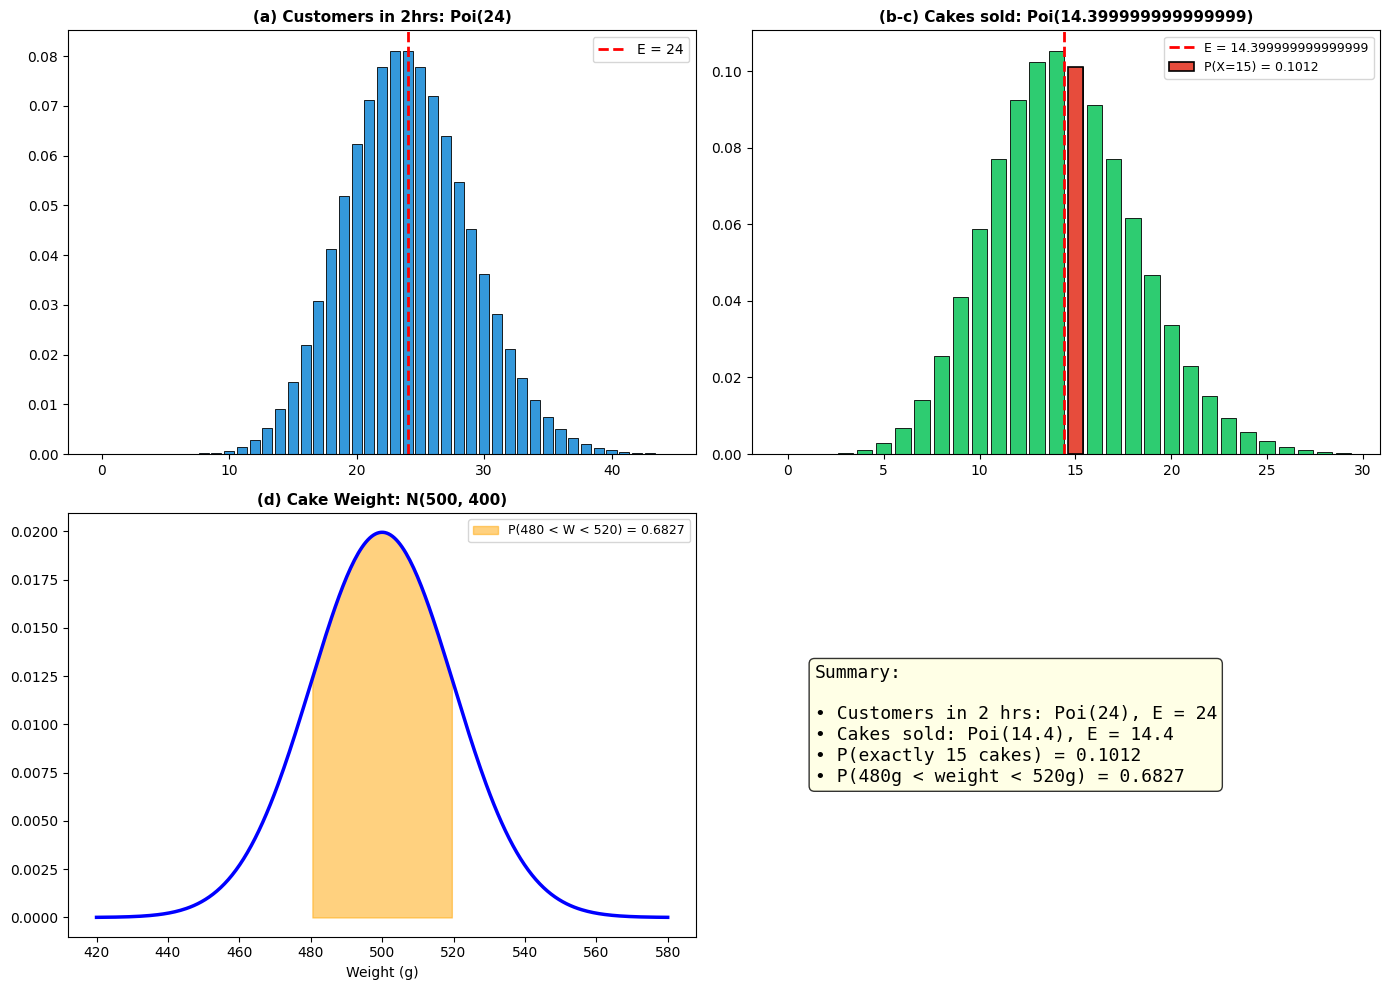

In [13]:
# Setup
lam_customers = 12  # per hour
p_cake = 0.6
mu_weight, sigma_weight = 500, 20

# (a) Customers in 2 hours: Poi(24)
lam_2hr = lam_customers * 2
print(f"(a) Customers in 2 hrs ~ Poi(λ = {lam_2hr})")
print(f"    E[customers] = {lam_2hr}")
print()

# (b) Expected cakes = E[customers] × p_cake
# Actually: each customer independently buys → cakes ~ Poi(λ × p)
# By thinning property: Poi(24) with p=0.6 → cakes ~ Poi(14.4)
lam_cakes = lam_2hr * p_cake
print(f"(b) By Poisson thinning: cakes ~ Poi(λ = {lam_cakes})")
print(f"    E[cakes] = {lam_cakes}")
print()

# (c) P(exactly 15 cakes)
X_cakes = stats.poisson(lam_cakes)
p_c = X_cakes.pmf(15)
print(f"(c) P(X = 15) = {p_c:.6f}")
print()

# (d) Cake weight
W = stats.norm(mu_weight, sigma_weight)
p_d = W.cdf(520) - W.cdf(480)
z1, z2 = (480 - mu_weight) / sigma_weight, (520 - mu_weight) / sigma_weight
print(f"(d) P(480 < W < 520)")
print(f"    z-scores: ({z1}, {z2})")
print(f"    P = Φ({z2}) - Φ({z1}) = {p_d:.6f} = {p_d*100:.2f}%")

# Visualize all parts
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# (a) Customer arrivals
ax = axes[0, 0]
k = np.arange(0, 45)
ax.bar(k, stats.poisson(lam_2hr).pmf(k), color='#3498db', edgecolor='black', linewidth=0.6)
ax.axvline(lam_2hr, color='red', linewidth=2, linestyle='--', label=f'E = {lam_2hr}')
ax.set_title(f'(a) Customers in 2hrs: Poi({lam_2hr})', fontsize=11, fontweight='bold')
ax.legend()

# (b) Cakes sold
ax = axes[0, 1]
k = np.arange(0, 30)
ax.bar(k, X_cakes.pmf(k), color='#2ecc71', edgecolor='black', linewidth=0.6)
ax.axvline(lam_cakes, color='red', linewidth=2, linestyle='--', label=f'E = {lam_cakes}')
ax.bar(15, X_cakes.pmf(15), color='#e74c3c', edgecolor='black', linewidth=1.2,
       label=f'P(X=15) = {p_c:.4f}')
ax.set_title(f'(b-c) Cakes sold: Poi({lam_cakes})', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)

# (d) Cake weight
ax = axes[1, 0]
x = np.linspace(420, 580, 300)
ax.plot(x, W.pdf(x), 'b-', linewidth=2.5)
mask = (x >= 480) & (x <= 520)
ax.fill_between(x[mask], W.pdf(x[mask]), alpha=0.5, color='orange',
               label=f'P(480 < W < 520) = {p_d:.4f}')
ax.set_title('(d) Cake Weight: N(500, 400)', fontsize=11, fontweight='bold')
ax.set_xlabel('Weight (g)')
ax.legend(fontsize=9)

# Summary
ax = axes[1, 1]
ax.axis('off')
summary = (
    "Summary:\n\n"
    f"• Customers in 2 hrs: Poi(24), E = 24\n"
    f"• Cakes sold: Poi(14.4), E = 14.4\n"
    f"• P(exactly 15 cakes) = {p_c:.4f}\n"
    f"• P(480g < weight < 520g) = {p_d:.4f}"
)
ax.text(0.1, 0.5, summary, fontsize=13, va='center', family='monospace',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.show()

---
## Summary of Examples

| # | Problem | Distribution | Key Technique |
|---|---------|-------------|---------------|
| 1.1 | Spam filter | Bin(20, 0.05) | PMF, CDF |
| 1.2 | Quality control | Bin(500, 0.02) | Normal & Poisson approximation |
| 2.1 | Website traffic | Poi(4) | Scaling λ with interval |
| 2.2 | Rare disease | Poi(3) | Poisson limit of Binomial |
| 3.1 | Debugging | Geo(0.3) | Memoryless property |
| 4.1 | Recruiting | NegBin(5, 0.2) | Trials until r-th success |
| 5.1 | Bus wait | Uni(0, 15) | Length = probability |
| 5.2 | Server failures | Exp(1/200) | Memoryless, median < mean |
| 6.1 | Exam scores | N(72, 100) | Z-scores, percentiles |
| 6.2 | Steel rods | N(50, σ²) | Tolerance, finding σ |
| 7.1 | Identify dist. | Various | Decision framework |
| 7.2 | Bakery | Poi + Bern + N | Poisson thinning, combining distributions |